In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
import re
from bokeh.plotting import figure, show
from bokeh.io import output_notebook, show
from bokeh.models import ColumnDataSource,  DataTable , TableColumn,HTMLTemplateFormatter,HoverTool, Select, CustomJS
from bokeh.layouts import column
output_notebook()  
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8') 

Loading BokehJS ...

In [2]:
df = pd.read_csv("kl.csv", encoding="latin1")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18207 entries, 0 to 18206
Data columns (total 89 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                18207 non-null  int64  
 1   ID                        18207 non-null  int64  
 2   Name                      18207 non-null  str    
 3   Age                       18206 non-null  float64
 4   Photo                     18207 non-null  str    
 5   Nationality               18207 non-null  str    
 6   Flag                      18207 non-null  str    
 7   Overall                   18206 non-null  float64
 8   Potential                 18207 non-null  int64  
 9   Club                      17966 non-null  str    
 10  Club Logo                 18207 non-null  str    
 11  Value                     18207 non-null  str    
 12  Wage                      18207 non-null  str    
 13  Special                   18207 non-null  int64  
 14  Preferred Foot   

In [4]:
df.describe(include="all")

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
count,18207.000000,18207.000000,18207,18206.000000,18207,18207,18207,18206.000000,18207.000000,17966,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,16643
unique,NaN,NaN,17194,NaN,18207,164,164,NaN,NaN,651,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1244
top,NaN,NaN,J. Rodríguez,NaN,https://cdn.sofifa.org/players/4/19/158023.png,England,https://cdn.sofifa.org/flags/14.png,NaN,NaN,FC Barcelona,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.1M
freq,NaN,NaN,11,NaN,1,1662,1662,NaN,NaN,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,557
mean,9103.000000,214298.338606,NaN,25.122048,NaN,NaN,NaN,66.237449,71.307299,NaN,...,58.648274,47.281623,47.697836,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887,NaN
std,5256.052511,29965.244204,NaN,4.670022,NaN,NaN,NaN,6.907059,6.136496,NaN,...,11.436133,19.904397,21.664004,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119,NaN
min,0.000000,16.000000,NaN,16.000000,NaN,NaN,NaN,46.000000,48.000000,NaN,...,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN
25%,4551.500000,200315.500000,NaN,21.000000,NaN,NaN,NaN,62.000000,67.000000,NaN,...,51.000000,30.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000,NaN
50%,9103.000000,221759.000000,NaN,25.000000,NaN,NaN,NaN,66.000000,71.000000,NaN,...,60.000000,53.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000,NaN
75%,13654.500000,236529.500000,NaN,28.000000,NaN,NaN,NaN,71.000000,75.000000,NaN,...,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000,NaN


In [5]:
df.nunique()

Unnamed: 0        18207
ID                18207
Name              17194
Age                  29
Photo             18207
                  ...  
GKHandling           70
GKKicking            79
GKPositioning        79
GKReflexes           76
Release Clause     1244
Length: 89, dtype: int64

In [6]:
df.isnull().sum()

Unnamed: 0           0
ID                   0
Name                 0
Age                  1
Photo                0
                  ... 
GKHandling          48
GKKicking           48
GKPositioning       48
GKReflexes          48
Release Clause    1564
Length: 89, dtype: int64

In [7]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
18202    False
18203    False
18204    False
18205    False
18206    False
Length: 18207, dtype: bool

In [8]:
df=df.drop(columns=['Unnamed: 0','Photo','Flag','Club Logo'])

In [ ]:
import re

def convert_money(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
     
    x = re.sub(r'[^\d.MK]', '', x)
    
    if x == '' or x == '0':
        return 0.0
    
    match = re.match(r'^([\d.]+)([MK]?)$', x)
    if not match:
        return np.nan
    
    number, suffix = match.groups()
    number = float(number)
    
    if suffix == 'M':
        return number * 1_000_000
    elif suffix == 'K':
        return number * 1_000
    else:
        return number

df['Value_num'] = df['Value'].apply(convert_money)
df['Wage_num'] = df['Wage'].apply(convert_money)

print(df['Value_num'].isnull().sum(), "out of", len(df))
print(df['Value_num'].describe())

0 out of 18207
count    1.820700e+04
mean     2.410696e+06
std      5.594933e+06
min      0.000000e+00
25%      3.000000e+05
50%      6.750000e+05
75%      2.000000e+06
max      1.185000e+08
Name: Value_num, dtype: float64


In [10]:
df.head()

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Special,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause,Value_num,Wage_num
0,158023,L. Messi,31.0,Argentina,94.0,94,FC Barcelona,110.5M,565K,2202,...,28.0,26.0,6.0,11.0,15.0,14.0,8.0,226.5M,110500000.0,565000.0
1,20801,Cristiano Ronaldo,33.0,Portugal,94.0,94,Juventus,77M,405K,2228,...,31.0,23.0,7.0,11.0,15.0,14.0,11.0,127.1M,77000000.0,405000.0
2,190871,Neymar Jr,26.0,Brazil,92.0,93,Paris Saint-Germain,118.5M,290K,2143,...,24.0,33.0,9.0,9.0,15.0,15.0,11.0,228.1M,118500000.0,290000.0
3,193080,De Gea,27.0,Spain,91.0,93,Manchester United,72M,260K,1471,...,21.0,13.0,90.0,85.0,87.0,88.0,94.0,138.6M,72000000.0,260000.0
4,192985,K. De Bruyne,27.0,Belgium,91.0,92,Manchester City,102M,355K,2281,...,58.0,51.0,15.0,13.0,5.0,10.0,13.0,196.4M,102000000.0,355000.0


In [11]:
selected_cols = ['Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed',
                  'Strength', 'Stamina', 'Interceptions', 'StandingTackle', 'Value_num']

In [12]:
skill_subset = ['Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed',
                 'Strength', 'Stamina', 'Interceptions', 'StandingTackle']

df[skill_subset] = df[skill_subset].fillna(0)

In [13]:
df['Value_num'] = df['Value_num'].fillna(df['Value_num'].median())

In [14]:
print(df[selected_cols].isnull().sum().sum())  

0


In [15]:
gk_cols = ['GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes']
outfield_skill_cols = ['Crossing','Finishing','HeadingAccuracy','ShortPassing','Volleys',
                       'Dribbling','Curve','FKAccuracy','LongPassing','BallControl',
                       'Acceleration','SprintSpeed','Agility','Reactions','Balance',
                       'ShotPower','Jumping','Stamina','Strength','LongShots',
                       'Aggression','Interceptions','Positioning','Vision','Penalties',
                       'Composure','Marking','StandingTackle','SlidingTackle']

df[gk_cols] = df[gk_cols].fillna(0)
df[outfield_skill_cols] = df[outfield_skill_cols].fillna(0)

In [16]:
position_cols = ['LS','ST','RS','LW','LF','CF','RF','RW','LAM','CAM','RAM','LM',
                  'LCM','CM','RCM','RM','LWB','LDM','CDM','RDM','RWB','LB','LCB',
                  'CB','RCB','RB']
df[position_cols] = df[position_cols].fillna(0)

In [17]:
df['Loaned From'] = df['Loaned From'].fillna('Not on loan')

In [18]:
print(df['Club'].isnull().sum())

241


In [19]:
df=df.dropna(subset=['Club'])

In [20]:
df = df.drop_duplicates()

In [21]:
num_col = df.select_dtypes(include=[np.number]).columns.to_list()

q1 = df[num_col].quantile(0.25)
q3 = df[num_col].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr


df[num_col] = df[num_col].clip(
    lower=lower_bound, upper=upper_bound, axis=1
)
 

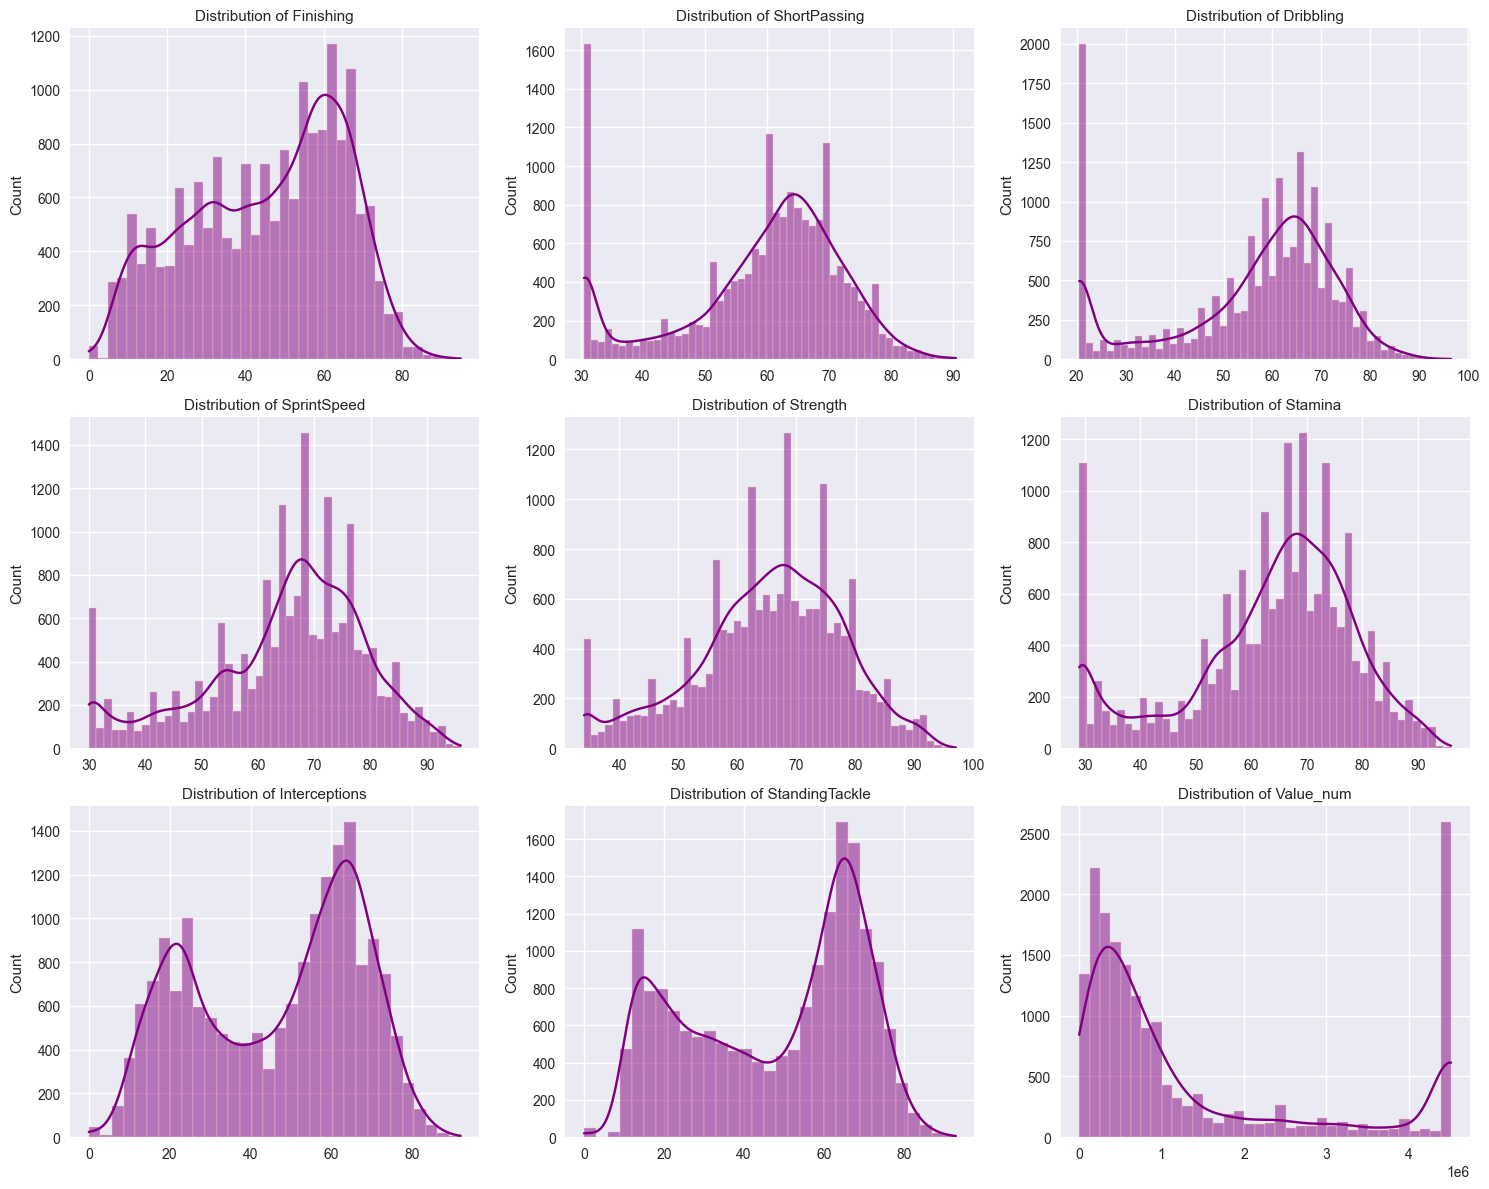

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='purple',edgecolor='Pink')
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

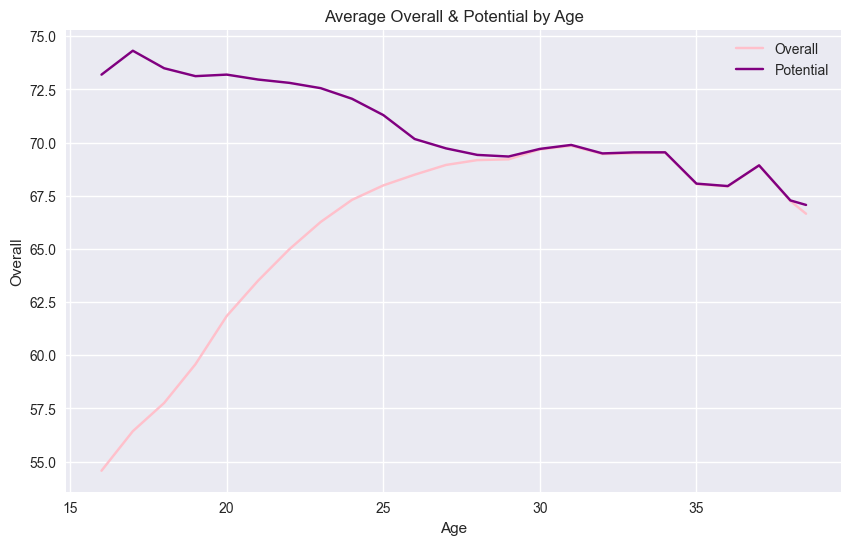

In [23]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Age', y='Overall', label='Overall', errorbar=None ,color='Pink')
sns.lineplot(data=df, x='Age', y='Potential', label='Potential', errorbar=None ,color='Purple')
plt.title('Average Overall & Potential by Age')
plt.show()

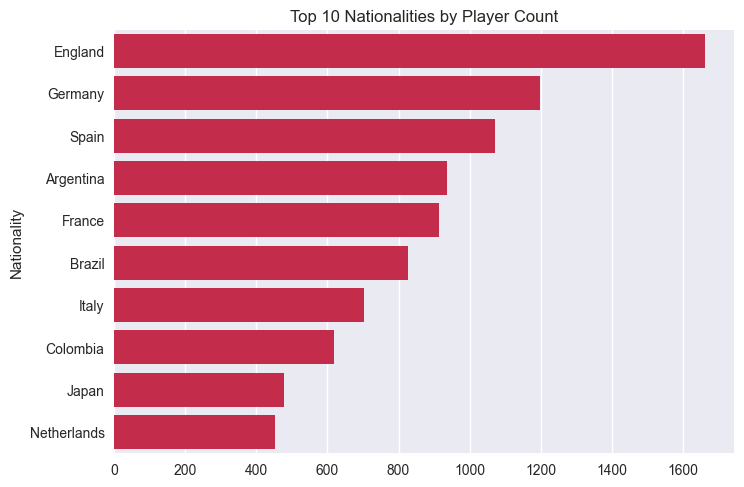

In [24]:
top_nations = df['Nationality'].value_counts().head(10)
sns.barplot(x=top_nations.values, y=top_nations.index ,color='crimson')
plt.title('Top 10 Nationalities by Player Count')
plt.show()

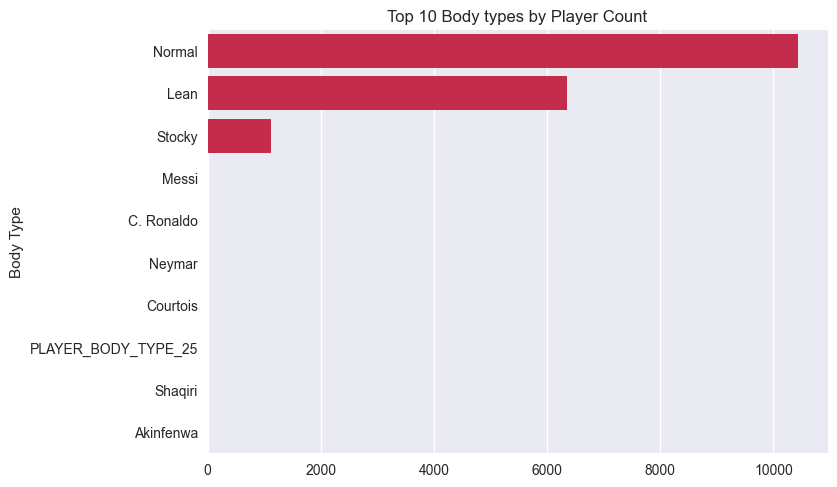

In [25]:
top_body = df['Body Type'].value_counts().head(10)
sns.barplot(x=top_body.values, y=top_body.index ,color='crimson')
plt.title('Top 10 Body types by Player Count')
plt.show()

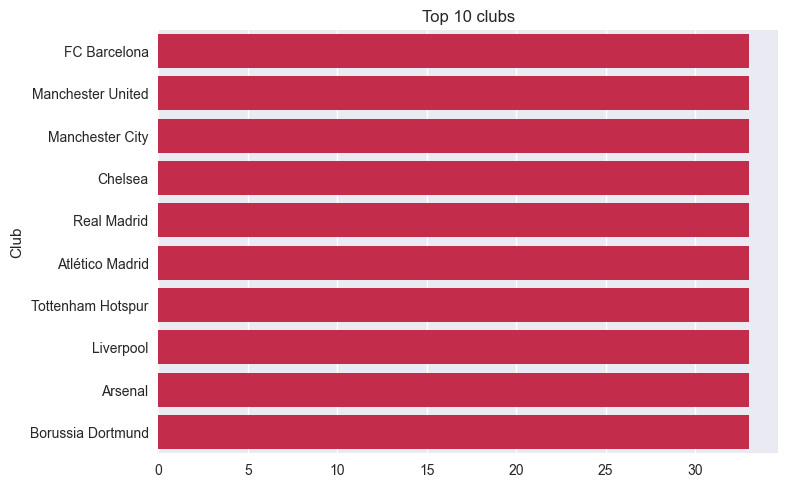

In [26]:
top_club = df['Club'].value_counts().head(10)
sns.barplot(x=top_club.values, y=top_club.index , color='crimson')
plt.title('Top 10 clubs')
plt.show()

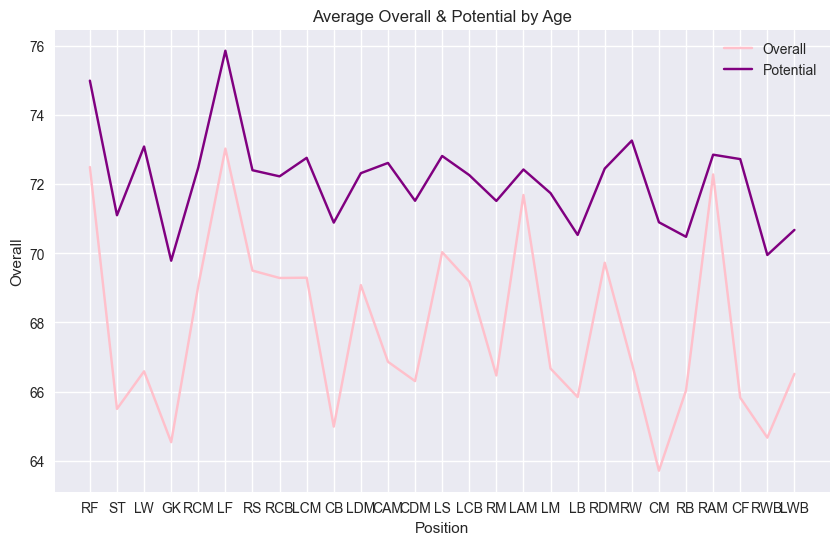

In [27]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Position', y='Overall', label='Overall', errorbar=None ,color='pink')
sns.lineplot(data=df, x='Position', y='Potential', label='Potential', errorbar=None ,color='purple')
plt.title('Average Overall & Potential by Age')
plt.show()

In [28]:
X=df[selected_cols]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=selected_cols)
print(X_scaled.describe().loc[['mean','std']])  # mean ≈ 0, std ≈ 1 for all cols

         Finishing  ShortPassing     Dribbling  SprintSpeed      Strength  \
mean -1.518693e-16 -5.062310e-17  1.771809e-16     0.000000  4.809195e-16   
std   1.000028e+00  1.000028e+00  1.000028e+00     1.000028  1.000028e+00   

           Stamina  Interceptions  StandingTackle     Value_num  
mean  1.265578e-16   2.024924e-16    1.139020e-16 -1.012462e-16  
std   1.000028e+00   1.000028e+00    1.000028e+00  1.000028e+00  


In [30]:
cov_matrix = np.cov(X_scaled, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)  
print(cov_matrix)

Covariance matrix shape: (9, 9)
[[ 1.00005566  0.65853624  0.8281016   0.59718539  0.00635894  0.50755486
  -0.00605917 -0.0184401   0.347369  ]
 [ 0.65853624  1.00005566  0.82688743  0.52601869  0.1391126   0.69499603
   0.54285751  0.53723803  0.49112639]
 [ 0.8281016   0.82688743  1.00005566  0.71439186 -0.04130584  0.65455432
   0.2690414   0.27077746  0.40507397]
 [ 0.59718539  0.52601869  0.71439186  1.00005566 -0.07782633  0.60567914
   0.16193891  0.1763126   0.24407986]
 [ 0.00635894  0.1391126  -0.04130584 -0.07782633  1.00005566  0.27576041
   0.36740921  0.34285375  0.2209541 ]
 [ 0.50755486  0.69499603  0.65455432  0.60567914  0.27576041  1.00005566
   0.57915962  0.57196701  0.3244425 ]
 [-0.00605917  0.54285751  0.2690414   0.16193891  0.36740921  0.57915962
   1.00005566  0.94225403  0.23761527]
 [-0.0184401   0.53723803  0.27077746  0.1763126   0.34285375  0.57196701
   0.94225403  1.00005566  0.1923786 ]
 [ 0.347369    0.49112639  0.40507397  0.24407986  0.2209541   0

In [31]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues:
 [0.05568837 0.08808586 0.13275167 0.23803007 0.44937293 0.6796906
 0.95051418 2.01047156 4.39589574]
Eigenvectors shape: (9, 9)


In [32]:
# eigh returns eigenvalues in ASCENDING order, so we need to reverse
sorted_idx = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

print("Sorted eigenvalues (descending):\n", eigenvalues_sorted)

# check explained variance ratio
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)
cumulative_variance = np.cumsum(explained_variance_ratio)


Sorted eigenvalues (descending):
 [4.39589574 2.01047156 0.95051418 0.6796906  0.44937293 0.23803007
 0.13275167 0.08808586 0.05568837]


In [33]:
pca_summary = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Explained Variance (%)': explained_variance_ratio * 100,
    'Cumulative Variance (%)': cumulative_variance * 100
})

pca_summary

,Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,48.840567,48.840567
1,PC2,22.337329,71.177897
2,PC3,10.560681,81.738578
3,PC4,7.551697,89.290275
4,PC5,4.992755,94.283030
5,PC6,2.644631,96.927661
6,PC7,1.474936,98.402598
7,PC8,0.978677,99.381275
8,PC9,0.618725,100.000000


In [34]:
# I let the data projects on 4 components as at PC4 the commulative varience
#  89% as it collects large amount of data
n_components = 4 

projection_matrix = eigenvectors_sorted[:, :n_components]
print("Projection matrix shape:", projection_matrix.shape)  # (9, 4)

X_pca = X_scaled @ projection_matrix   # matrix multiplication
print("Final projected data shape:", X_pca.shape)  

Projection matrix shape: (9, 4)
Final projected data shape: (17966, 4)


In [35]:
X_pca = X_pca.values if isinstance(X_pca, pd.DataFrame) else X_pca

In [36]:
pca_plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1] ,
    'Class': df['Position'].values   
})

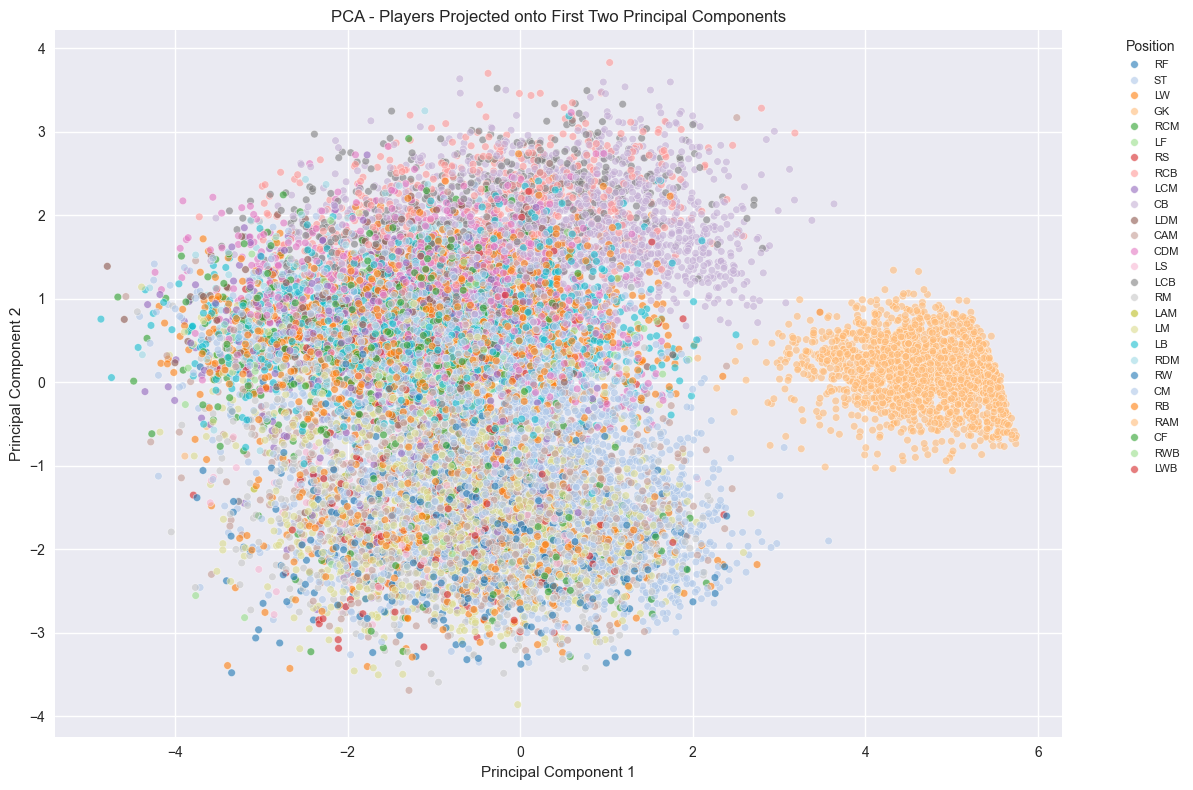

In [37]:

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_plot_df,
    x='PC1', y='PC2',
    hue='Class',
    palette='tab20',  
    alpha=0.6,
    s=30
)

plt.title('PCA - Players Projected onto First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title='Position')
plt.tight_layout()
plt.show()

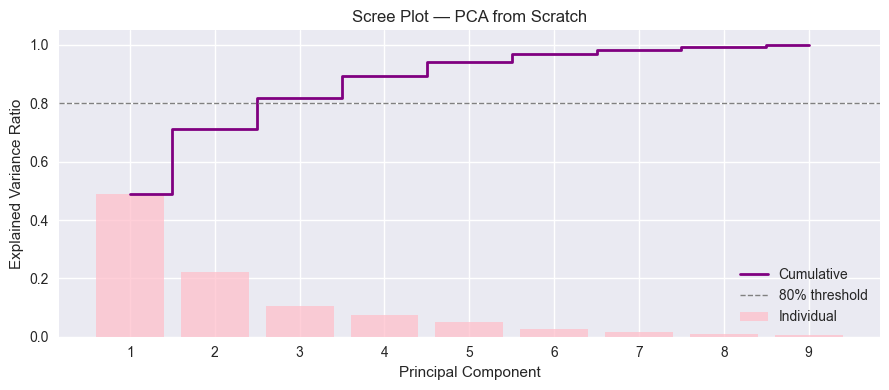

In [38]:

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio,
       alpha=0.75, color='pink', label='Individual')
ax.step(range(1, len(cumulative_variance)+1), cumulative_variance,
        where='mid', color='purple', linewidth=2, label='Cumulative')
ax.axhline(0.80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot — PCA from Scratch')
ax.set_xticks(range(1, len(explained_variance_ratio)+1))
ax.legend()
plt.tight_layout()
plt.show()

### Report about the PCA 

The main aim of the PCA is to reduce the dimensionality of the data to collect all the importanat data in small number of columns 

### Eigen vector : 
is the direction vector where the data going to project on .
### Eigen value :
 is the value of the vector which determine the lenght of the vector and we going to take the largest eigen value.
 

 here I let the data projects on 4 components as at PC4 the commulative varience
  89% as it collects large amount of data  as I can't make it only at two components as at first two PCA they collect 71% from the data which means that I have high varience in the data
  but when I visualize I visualize only two PCA as it is 2_D

## Task 2.3


In [39]:
X_scaled_arr = X_scaled.values if isinstance(X_scaled, pd.DataFrame) else X_scaled
print(type(X_scaled_arr), X_scaled_arr.shape)

<class 'numpy.ndarray'> (17966, 9)


In [40]:
 
salah_idx = df[df['Name'].str.contains('Salah', case=False, na=False)].index
print(df.loc[salah_idx, ['Name', 'Club', 'Nationality']])

        Name       Club Nationality
26  M. Salah  Liverpool       Egypt


In [41]:
salah_idx = salah_idx[0]
target_vector = X_scaled_arr[salah_idx]

In [42]:
def euclidean_distance(X, target_vector):
    diff = X - target_vector
    return np.sqrt(np.sum(diff**2, axis=1))

def manhattan_distance(X, target_vector):
    diff = np.abs(X - target_vector)
    return np.sum(diff, axis=1)

def cosine_similarity(X, target_vector):
    dot_product = X @ target_vector
    norm_X = np.linalg.norm(X, axis=1)
    norm_target = np.linalg.norm(target_vector)
    return dot_product / (norm_X * norm_target)

def pearson_correlation(X, target_vector):
    X_centered = X - X.mean(axis=1, keepdims=True)
    target_centered = target_vector - target_vector.mean()
    numerator = X_centered @ target_centered
    denom = np.linalg.norm(X_centered, axis=1) * np.linalg.norm(target_centered)
    return numerator / denom

In [43]:
euc_scores = euclidean_distance(X_scaled_arr, target_vector)
man_scores = manhattan_distance(X_scaled_arr, target_vector)
cos_scores = cosine_similarity(X_scaled_arr, target_vector)
pear_scores = pearson_correlation(X_scaled_arr, target_vector)

In [44]:
def get_top5(scores, higher_is_better, exclude_idx, names):
    scores = scores.copy()
    scores[exclude_idx] = -np.inf if higher_is_better else np.inf
    
    if higher_is_better:
        top_idx = np.argsort(scores)[::-1][:5]
    else:
        top_idx = np.argsort(scores)[:5]
    
    return pd.DataFrame({
        'Player': names.iloc[top_idx].values,
        'Score': scores[top_idx]
    })



In [45]:
Result = pd.DataFrame({
    "Euclidean": get_top5(euc_scores, False, salah_idx, df['Name'])['Player'].values,
    "Manhattan": get_top5(man_scores, False, salah_idx, df['Name'])['Player'].values,
    "Cosine Similarity": get_top5(cos_scores, True, salah_idx, df['Name'])['Player'].values,
    "Pearson Correlation": get_top5(pear_scores, True, salah_idx, df['Name'])['Player'].values,
})
Result

,Euclidean,Manhattan,Cosine Similarity,Pearson Correlation
0,A. Lacazette,K. Mbappé,J. Murphy,T. Werner
1,K. Mbappé,S. Mané,A. Lacazette,T. Torun
2,M. Reus,A. Lacazette,K. Mbappé,H. Son
3,S. Mané,A. Griezmann,A. Sánchez,E. Ba?san
4,A. Martial,M. Reus,M. Reus,Q. Promes


# Task 2.3: Scouting Engine — Similarity Report

**Target:** Mohamed Salah | **Features:** Finishing, ShortPassing, Dribbling, SprintSpeed, Strength, Stamina, Interceptions, StandingTackle, Value

## Top-5 Results (Standardized)

| Rank | Euclidean | Manhattan | Cosine Similarity | Pearson Correlation |
|------|-----------|-----------|--------------------|-----------------------|
| 1 | A. Lacazette | K. Mbappé | J. Murphy | T. Werner |
| 2 | K. Mbappé | S. Mané | A. Lacazette | T. Torun |
| 3 | M. Reus | A. Lacazette | K. Mbappé | H. Son |
| 4 | S. Mané | A. Griezmann | A. Sánchez | E. Başsan |
| 5 | A. Martial | M. Reus | M. Reus | Q. Promes |

## Metric Summary

- **Euclidean:** absolute distance across all stats — sensitive to overall stat level.
- **Manhattan:** sum of absolute differences — similar to Euclidean but less skewed by single large gaps.
- **Cosine Similarity:** compares profile *shape*, ignoring magnitude — surfaces players with a similar skill balance even at a different overall level.
- **Pearson Correlation:** cosine similarity on mean-centered data — measures pattern correlation only.

## Cross-Metric Comparison
Euclidean and Manhattan agree closely (4/5 shared players), since both are magnitude-sensitive. Cosine overlaps partially but introduces new names (J. Murphy, A. Sánchez) by focusing on relative shape. Pearson shares **no players** with the other three — it isolates pattern correlation independent of both magnitude and average level, producing a very different shortlist.

## Standardized vs. Raw Reflection
On raw (unscaled) data, `Value` (in the millions) dominates the distance calculation over 0–100 skill ratings, so "similar" effectively becomes "similar market value" rather than similar playing style. This confirms standardization is essential before any distance-based comparison.

## Final Recommendation
**Cosine Similarity** shortlist — A. Lacazette, K. Mbappé, A. Sánchez, M. Reus, J. Murphy — is recommended, since it best captures skill-profile similarity independent of overall stat level.

## PCA Visual Check
[Fill in: did the Cosine shortlist cluster near Salah in PC space? Confirms / contradicts the metric-based result.]

In [ ]:
Result_display = Result.copy()
Result_display.insert(0, 'Rank', range(1, len(Result_display) + 1))  

source = ColumnDataSource(Result_display)

template = """
<div style="background-color: #D8BFD8; padding: 4px;">
    <%= value %>
</div>
"""

columns = []
for col in Result_display.columns:
            columns.append(TableColumn(
            field=col, title=col,
            formatter=HTMLTemplateFormatter(template=template)
        ))


data_table = DataTable(source=source, columns=columns, width=800, height=200)
show(data_table)


In [47]:
X_raw_arr = df[selected_cols].values   
target_raw = X_raw_arr[salah_idx] 

In [48]:
euc_raw = euclidean_distance(X_raw_arr, target_raw)
man_raw = manhattan_distance(X_raw_arr, target_raw)
cos_raw = cosine_similarity(X_raw_arr, target_raw)
pear_raw = pearson_correlation(X_raw_arr, target_raw)

In [49]:
Row_result=pd.DataFrame({
    'Eculidien': get_top5(euc_raw,False,salah_idx,df['Name'])['Player'].values,
    'Manhatan': get_top5(man_raw,False,salah_idx,df['Name'])['Player'].values,
    'Cocine_similarty': get_top5(cos_raw,True,salah_idx,df['Name'])['Player'].values,
    'Pearson_correlation': get_top5(pear_raw,True,salah_idx,df['Name'])['Player'].values
}) 

Row_result

,Eculidien,Manhatan,Cocine_similarty,Pearson_correlation
0,M. Reus,K. Mbappé,M. Reus,Y. Mut?
1,A. Lacazette,A. Lacazette,A. Lacazette,W. Ben Yedder
2,E. Vi?a,S. Mané,T. Elyounoussi,M. Gradel
3,Marlos,M. Reus,A. Traoré,N. De Préville
4,A. Martial,A. Griezmann,M. itum,Ivi


In [50]:
 
std_top5 = get_top5(man_scores, False, salah_idx, df['Name']).reset_index(drop=True)
raw_top5 = get_top5(man_raw, False, salah_idx, df['Name']).reset_index(drop=True)

std_top5['Rank'] = range(1, 6)
raw_top5['Rank'] = range(1, 6)

p = figure(
    x_range=['Standardized', 'Raw'],
    y_range=(5.5, 0.5), 
    title="Player Rank Shift: Standardized vs Raw (Manhatn)",
    width=600, height=450,
    tools=[HoverTool(tooltips=[('Player', '@Player')])]
)

 
all_players = set(std_top5['Player']) | set(raw_top5['Player'])

for player in all_players:
    std_rank = std_top5[std_top5['Player'] == player]['Rank'].values
    raw_rank = raw_top5[raw_top5['Player'] == player]['Rank'].values
    
    std_rank = std_rank[0] if len(std_rank) else None
    raw_rank = raw_rank[0] if len(raw_rank) else None
    
    if std_rank and raw_rank:
        p.line(['Standardized', 'Raw'], [std_rank, raw_rank], line_width=2, color='purple', alpha=0.6)
    
    if std_rank:
        p.scatter(['Standardized'], [std_rank], size=10, color='navy')
        p.text(['Standardized'], [std_rank], text=[player], x_offset=-10, text_align='right', text_font_size='8pt')
    if raw_rank:
        p.scatter(['Raw'], [raw_rank], size=10, color='crimson')
        p.text(['Raw'], [raw_rank], text=[player], x_offset=10, text_align='left', text_font_size='8pt')

show(p)
 

## Bonus Task2.2  && Task2.3


In [51]:
X_list = X.tolist() if hasattr(X, 'tolist') else X
 

In [52]:
 

if isinstance(X, pd.DataFrame):
    X_list = X.values.tolist()
elif isinstance(X, np.ndarray):
    X_list = X.tolist()
else:
    X_list = X

print(type(X_list))          
print(type(X_list[0]))       
print(len(X_list), len(X_list[0]))

<class 'list'>
<class 'list'>
17966 9


In [53]:
def transpose(matrix):
    return [[row[i] for row in matrix] for i in range(len(matrix[0]))]

In [54]:
def matrix_multiply(A, B):
    rows_A, cols_A = len(A), len(A[0])
    rows_B, cols_B = len(B), len(B[0])
    result = [[0.0 for _ in range(cols_B)] for _ in range(rows_A)]
    for i in range(rows_A):
        for j in range(cols_B):
            total = 0.0
            for k in range(cols_A):
                total += A[i][k] * B[k][j]
            result[i][j] = total
    return result

In [55]:
def standardize(matrix):
    n_rows, n_cols = len(matrix), len(matrix[0])
    standardized = [[0.0]*n_cols for _ in range(n_rows)]
    for col in range(n_cols):
        col_vals = [matrix[row][col] for row in range(n_rows)]
        mean = sum(col_vals) / n_rows
        variance = sum((x - mean)**2 for x in col_vals) / n_rows
        std = variance ** 0.5
        for row in range(n_rows):
            standardized[row][col] = (matrix[row][col] - mean) / std
    return standardized

In [56]:
def covariance_matrix(standardized_data):
    n = len(standardized_data)
    data_T = transpose(standardized_data)
    cov = matrix_multiply(data_T, standardized_data)
    n_features = len(cov)
    for i in range(n_features):
        for j in range(n_features):
            cov[i][j] /= (n - 1)
    return cov

In [57]:
def project_data(standardized_data, projection_matrix):
    return matrix_multiply(standardized_data, projection_matrix)

In [58]:
import time

start = time.time()

mean = X_pca.mean(axis=0)
std = X_pca.std(axis=0)
X_scaled_numpy = (X_pca - mean) / std

cov_np = np.cov(X_scaled_numpy, rowvar=False)
eigenvalues_np, eigenvectors_np = np.linalg.eigh(cov_np)

sorted_idx = np.argsort(eigenvalues_np)[::-1]
eigenvectors_sorted_np = eigenvectors_np[:, sorted_idx]

projection_matrix_np = eigenvectors_sorted_np[:, :2]
X_pca_numpy = X_scaled_numpy @ projection_matrix_np

numpy_time = time.time() - start
print(f"NumPy pipeline time: {numpy_time:.4f} seconds")

NumPy pipeline time: 0.0023 seconds


In [59]:
start = time.time()

X_standardized_manual = standardize(X_list)
cov_manual = covariance_matrix(X_standardized_manual)

 
eigenvalues_manual, eigenvectors_manual = np.linalg.eig(np.array(cov_manual))

sorted_idx_manual = np.argsort(eigenvalues_manual)[::-1]
eigenvectors_sorted_manual = eigenvectors_manual[:, sorted_idx_manual]

projection_matrix_manual = eigenvectors_sorted_manual[:, :2].tolist()   

X_pca_manual = project_data(X_standardized_manual, projection_matrix_manual)

manual_time = time.time() - start
print(f"Pure Python pipeline time: {manual_time:.4f} seconds")

Pure Python pipeline time: 0.1598 seconds


In [60]:
print(f"NumPy time:       {numpy_time:.4f} sec")
print(f"Pure Python time: {manual_time:.4f} sec")
print(f"NumPy is {manual_time / numpy_time:.1f}x faster")

NumPy time:       0.0023 sec
Pure Python time: 0.1598 sec
NumPy is 69.0x faster


In [61]:
X_pca_manual_arr = np.array(X_pca_manual)
print("Results match:", np.allclose(np.abs(X_pca_numpy[:, :2]), np.abs(X_pca_manual_arr[:, :2]), atol=1e-4))

Results match: False


In [62]:
 
cov_matrix_all = np.cov(X_scaled_arr, rowvar=False)
eigenvalues_all, eigenvectors_all = np.linalg.eigh(cov_matrix_all)

sorted_idx_all = np.argsort(eigenvalues_all)[::-1]
eigenvectors_sorted_all = eigenvectors_all[:, sorted_idx_all]

projection_matrix_all = eigenvectors_sorted_all[:, :2]
X_pca_all = X_scaled_arr @ projection_matrix_all    

In [ ]:
 
def get_top5_indices(scores, higher_is_better, exclude_idx):
    scores = scores.copy()
    scores[exclude_idx] = -np.inf if higher_is_better else np.inf
    if higher_is_better:
        return np.argsort(scores)[::-1][:5]
    else:
        return np.argsort(scores)[:5]

euc_idx = get_top5_indices(euc_scores, False, salah_idx)
man_idx = get_top5_indices(man_scores, False, salah_idx)
cos_idx = get_top5_indices(cos_scores, True, salah_idx)
pear_idx = get_top5_indices(pear_scores, True, salah_idx)
 
plot_df = pd.DataFrame({
    'PC1': X_pca_all[:, 0],
    'PC2': X_pca_all[:, 1],
    'Name': df['Name'].values,
    'Position': df['Position'].values,
})

plot_df['Group'] = 'All Players'
plot_df.loc[euc_idx, 'Group'] = 'Euclidean Shortlist'
plot_df.loc[man_idx, 'Group'] = 'Manhattan Shortlist'
plot_df.loc[cos_idx, 'Group'] = 'Cosine Shortlist'
plot_df.loc[pear_idx, 'Group'] = 'Pearson Shortlist'
plot_df.loc[salah_idx, 'Group'] = 'M. Salah'   
graph = figure(
    title="PCA Space: Salah and Shortlists (All Metrics)",
    width=800, height=600,
    tools="pan,wheel_zoom,box_zoom,reset,save",
    x_axis_label='PC1',
    y_axis_label='PC2'
)

hover = HoverTool(tooltips=[
    ('Player', '@Name'),
    ('Position', '@Position'),
    ('Group', '@Group'),
])
graph.add_tools(hover)
 
all_players_df = plot_df[plot_df['Group'] == 'All Players']
source_all = ColumnDataSource(all_players_df)
graph.scatter('PC1', 'PC2', source=source_all, size=6, color='pink',
              alpha=0.3, legend_label='All Players')

 
metric_colors = {
    'Euclidean Shortlist': 'orange',
    'Manhattan Shortlist': 'blue',
    'Cosine Shortlist': 'green',
    'Pearson Shortlist': 'purple',
}

for group_name, color in metric_colors.items():
    group_df = plot_df[plot_df['Group'] == group_name]
    source = ColumnDataSource(group_df)
    graph.scatter('PC1', 'PC2', source=source, size=12, color=color,
                  alpha=0.85, legend_label=group_name)

 
salah_df = plot_df[plot_df['Group'] == 'M. Salah']
source_salah = ColumnDataSource(salah_df)
graph.scatter('PC1', 'PC2', source=source_salah, size=20, color='red',
              marker='star', legend_label='M. Salah')

graph.legend.click_policy = "hide"
graph.legend.location = "top_left"

show(graph)

## Addational Task 

Comparison between PCA from scratch and the Sklearn library


In [64]:
from sklearn.decomposition import PCA

In [65]:
pca_sklearn    = PCA(n_components=2)
X_pca_sklearn = pca_sklearn.fit_transform(X_scaled_arr)

In [66]:
print(f"  PC1 explained_varience_ratio : {pca_sklearn.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2 explains_varience_ratio  : {pca_sklearn.explained_variance_ratio_[1]*100:.2f}%")

  PC1 explained_varience_ratio : 48.84%
  PC2 explains_varience_ratio  : 22.34%


In [67]:
comparison_evr_df = pd.DataFrame({
    "PC": ["PC1", "PC2"],
    "Scratch EVR": [
        f"{explained_variance_ratio[0]*100:.2f}%",
        f"{explained_variance_ratio[1]*100:.2f}%"
    ],
    "Sklearn EVR": [
        f"{pca_sklearn.explained_variance_ratio_[0]*100:.2f}%",
        f"{pca_sklearn.explained_variance_ratio_[1]*100:.2f}%"
    ],
    "Match": [
        "✓" if abs(explained_variance_ratio[0] - pca_sklearn.explained_variance_ratio_[0]) < 1e-4 else "✗",
        "✓" if abs(explained_variance_ratio[1] - pca_sklearn.explained_variance_ratio_[1]) < 1e-4 else "✗"
    ],
     
})

comparison_evr_df

,PC,Scratch EVR,Sklearn EVR,Match
0,PC1,48.84%,48.84%,✓
1,PC2,22.34%,22.34%,✓


Here I make an additional task theat I compare bewteen the Sklearn and scratch to make sure that I'm right 